In [138]:
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots


# DATASET: PREÇO

array([<Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>], dtype=object)

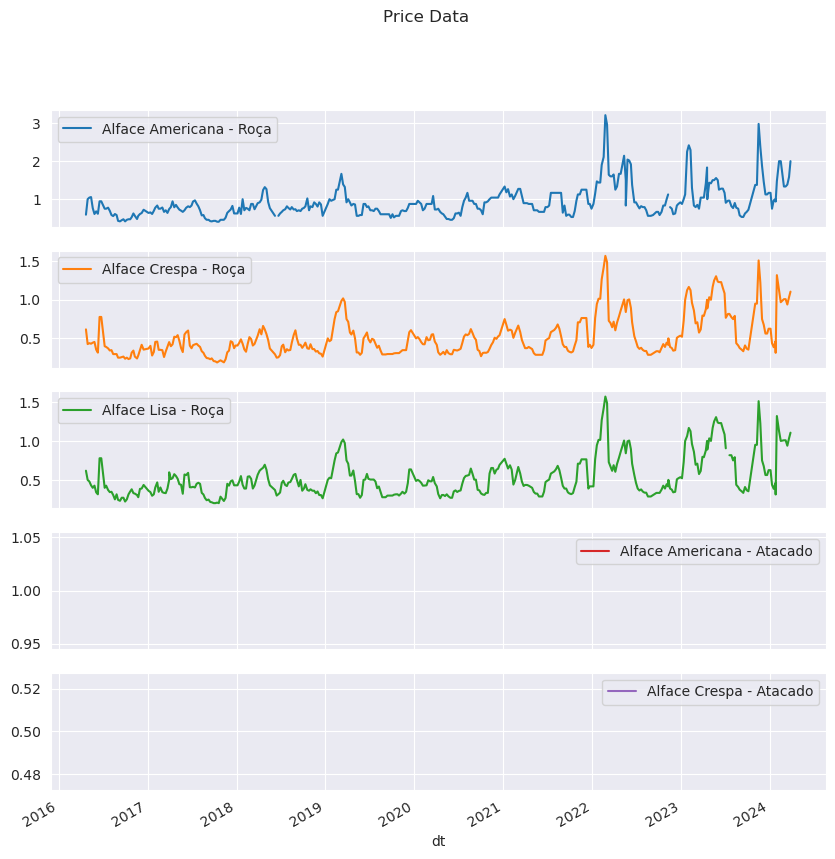

In [139]:
price_df = pd.read_csv('../../processed_data/prices-2016-2024.csv', index_col='dt', parse_dates=True)
price_df.plot(subplots=True, figsize=(10, 10), title='Price Data')



In [140]:
#count the number of NaN values in each column
price_nan_df = pd.DataFrame(price_df.isna().sum().sort_values(ascending=False))
price_nan_df.columns = ['Ausentes']
#rename index
price_nan_df.index.name = 'Coluna'
price_nan_df['% Ausentes'] = price_nan_df['Ausentes'] / len(price_df) * 100
price_nan_df

,Ausentes,% Ausentes
Coluna,,
Alface Crespa - Atacado,398,99.749373
Alface Americana - Atacado,398,99.749373
Alface Americana - Roça,2,0.501253
Alface Lisa - Roça,1,0.250627
Alface Crespa - Roça,0,0.000000


# DATASET: CLIMA

In [141]:
weather_df = pd.read_csv('../../processed_data/weather_2016_2023.csv', index_col='dt', parse_dates=True)
weather_df.drop(columns=['x'], inplace=True)

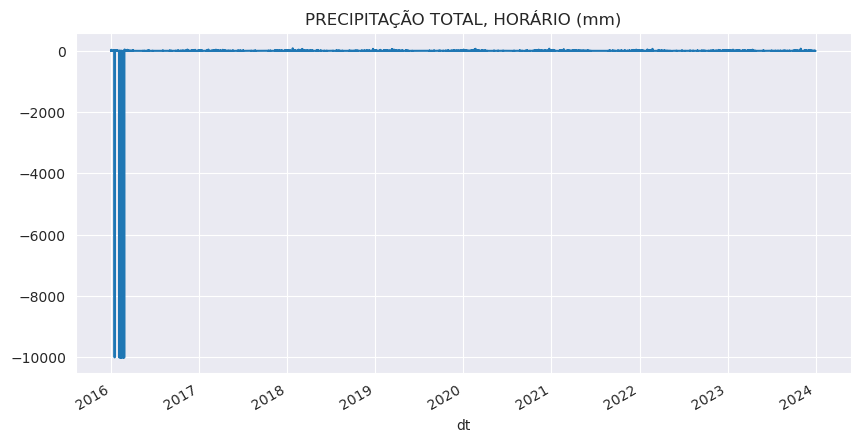

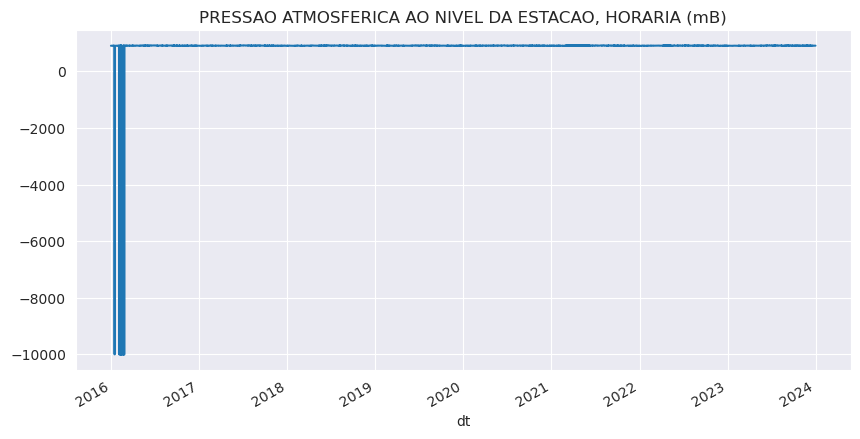

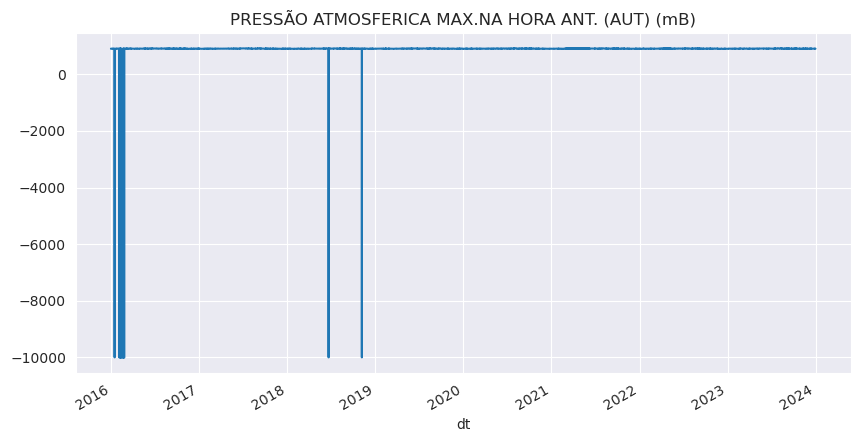

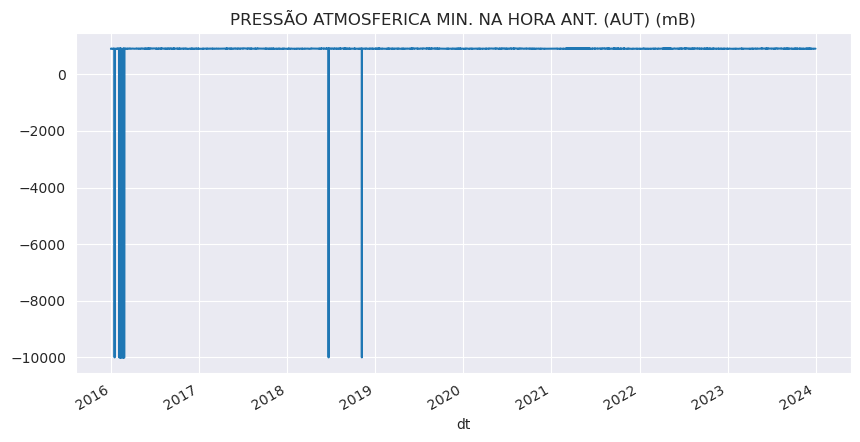

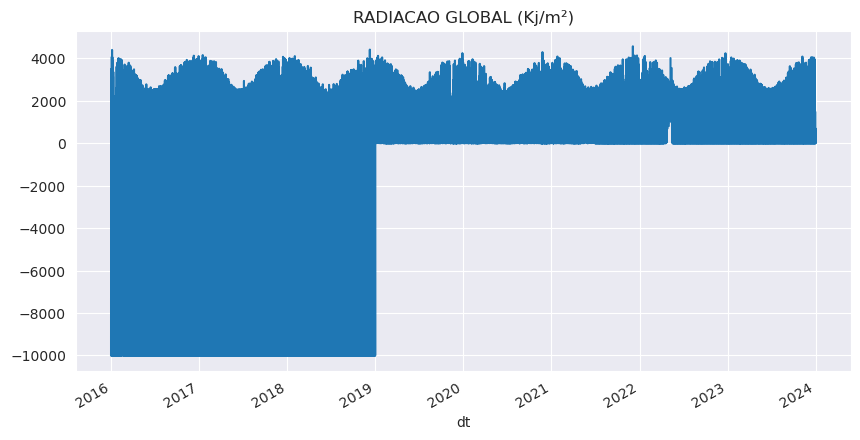

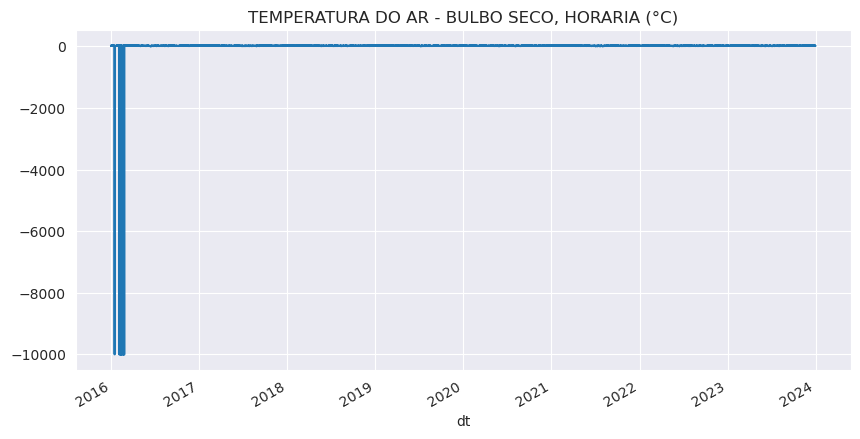

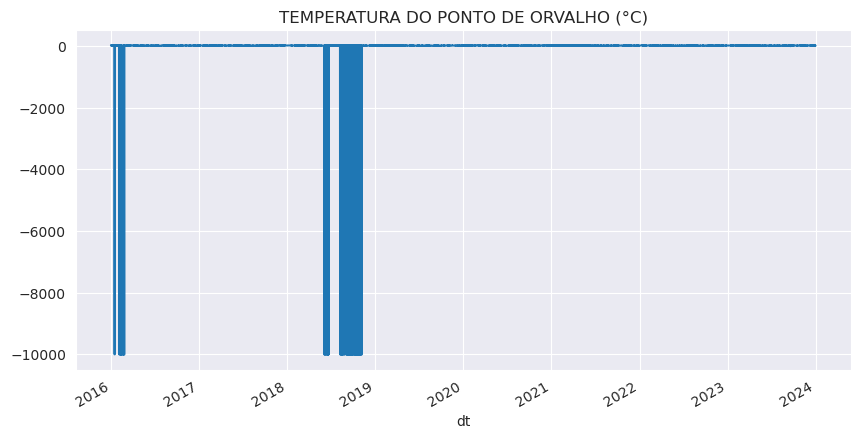

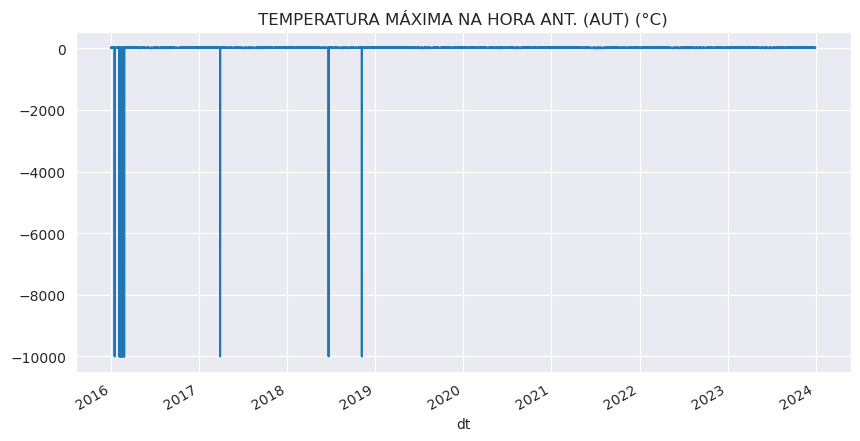

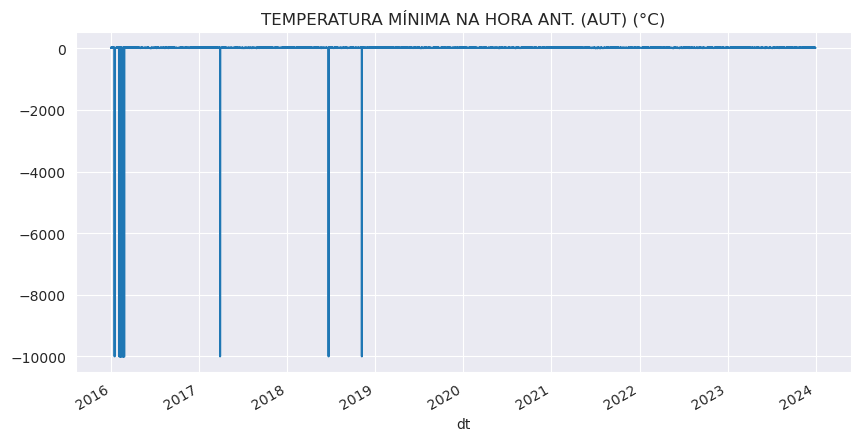

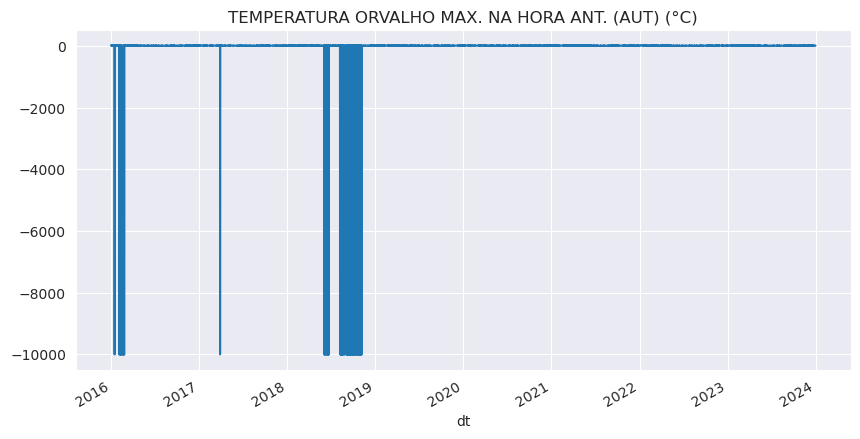

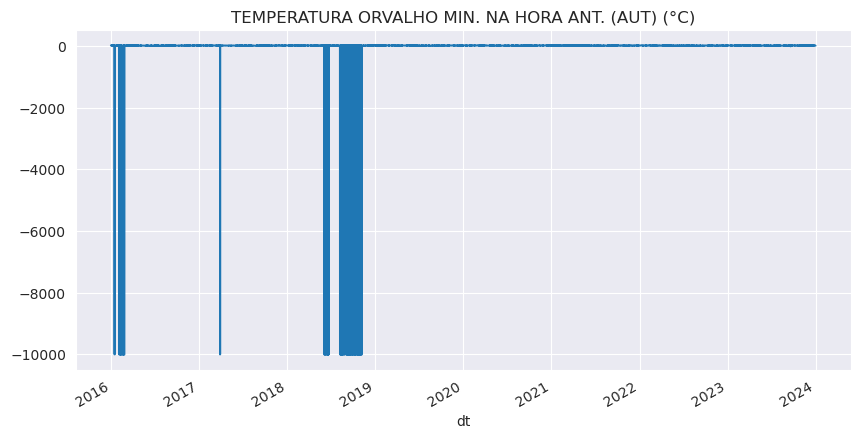

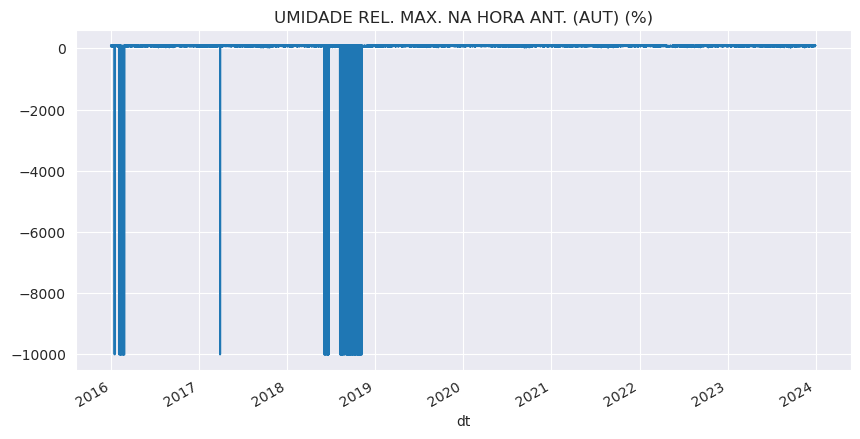

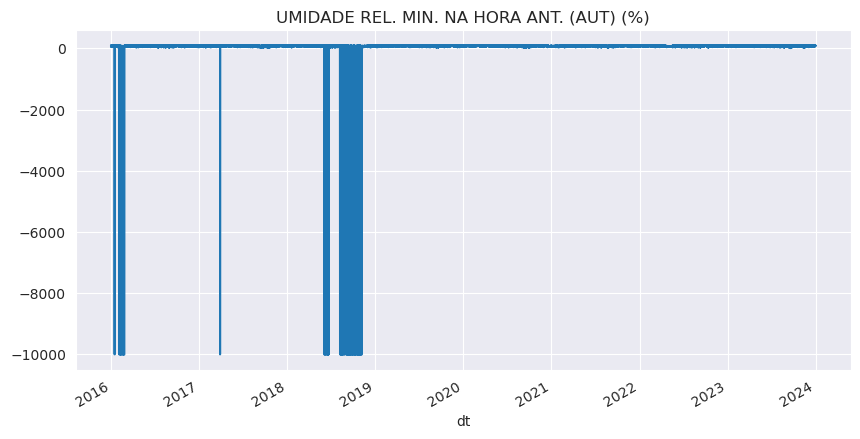

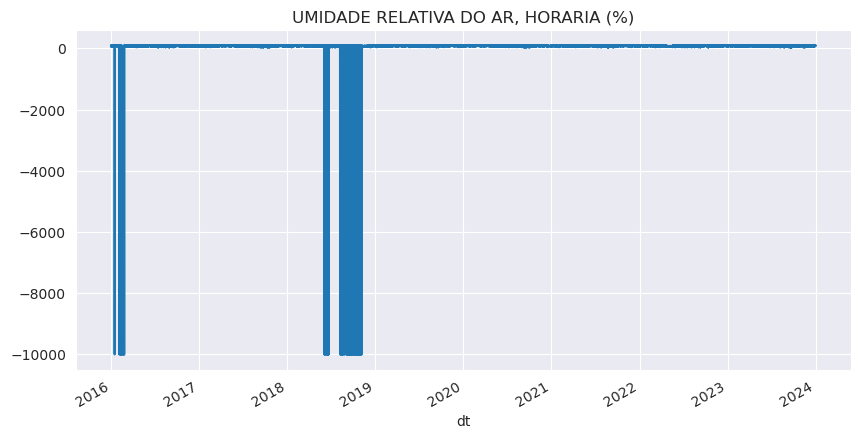

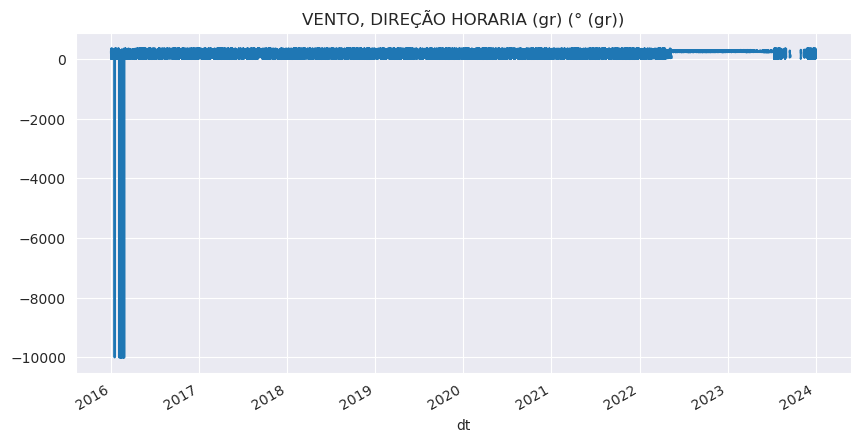

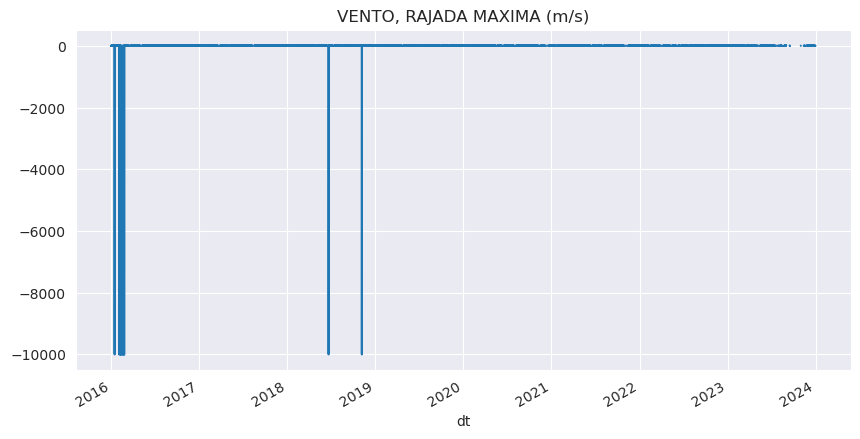

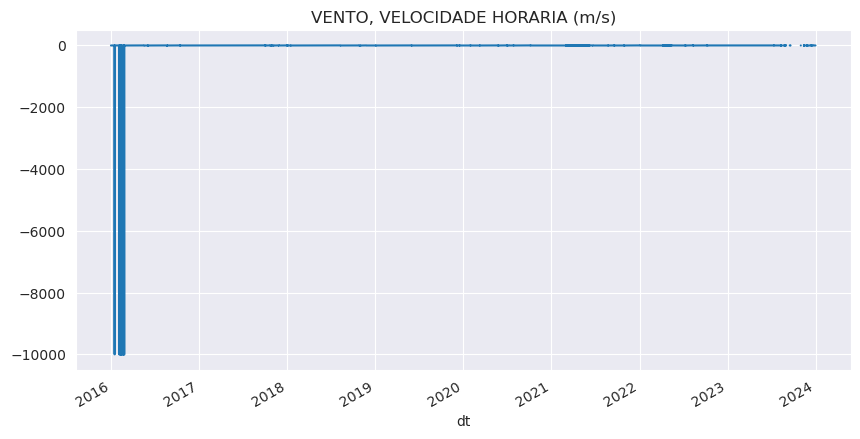

In [142]:
for col in weather_df.columns:
    weather_df[col].plot(figsize=(10, 5), title=col)
    plt.show()


In [143]:
"""
['Alface Americana - Roça',
 'Alface Crespa - Roça',
 'Alface Lisa - Roça',
 'Alface Americana - Atacado',
 'Alface Crespa - Atacado',
 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
 'RADIACAO GLOBAL (Kj/m²)',
 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
 'TEMPERATURA DO PONTO DE ORVALHO (°C)',
 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
 'UMIDADE RELATIVA DO AR, HORARIA (%)',
 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',
 'VENTO, RAJADA MAXIMA (m/s)',
 'VENTO, VELOCIDADE HORARIA (m/s)']
"""

"\n['Alface Americana - Roça',\n 'Alface Crespa - Roça',\n 'Alface Lisa - Roça',\n 'Alface Americana - Atacado',\n 'Alface Crespa - Atacado',\n 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',\n 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',\n 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',\n 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',\n 'RADIACAO GLOBAL (Kj/m²)',\n 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',\n 'TEMPERATURA DO PONTO DE ORVALHO (°C)',\n 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',\n 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',\n 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',\n 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',\n 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',\n 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',\n 'UMIDADE RELATIVA DO AR, HORARIA (%)',\n 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',\n 'VENTO, RAJADA MAXIMA (m/s)',\n 'VENTO, VELOCIDADE HORARIA (m/s)']\n"

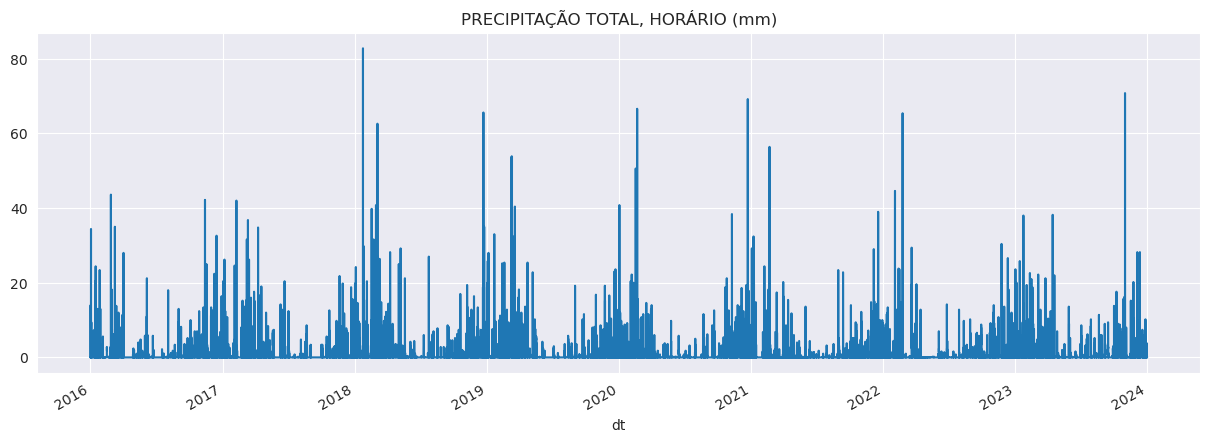

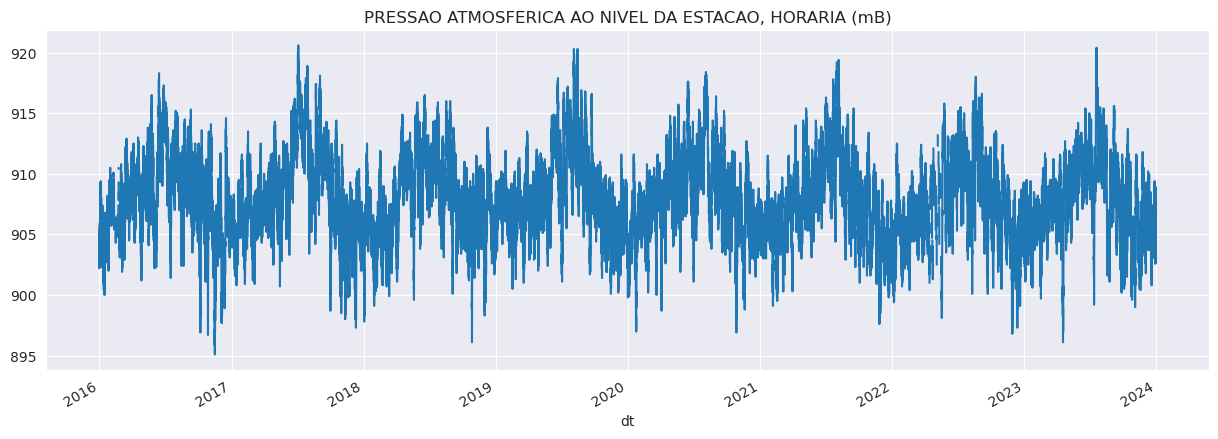

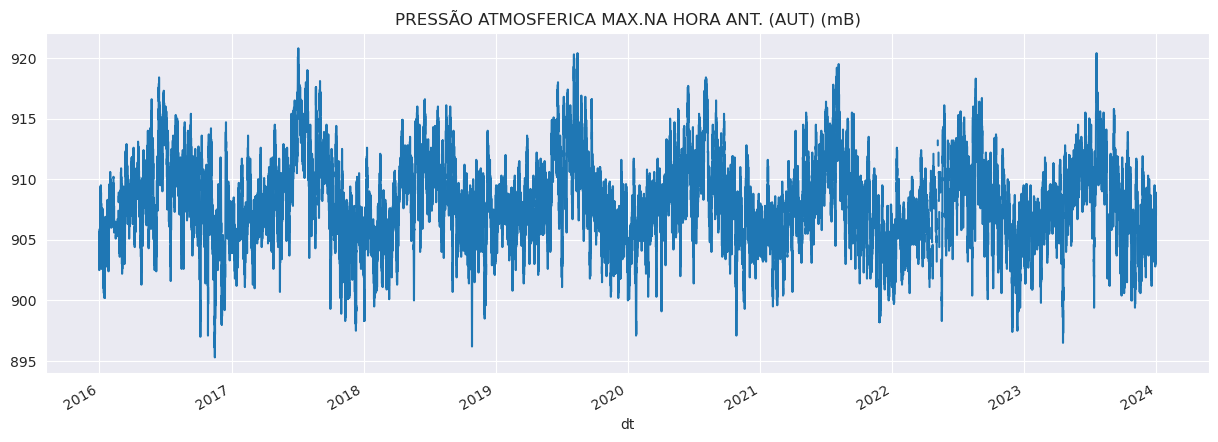

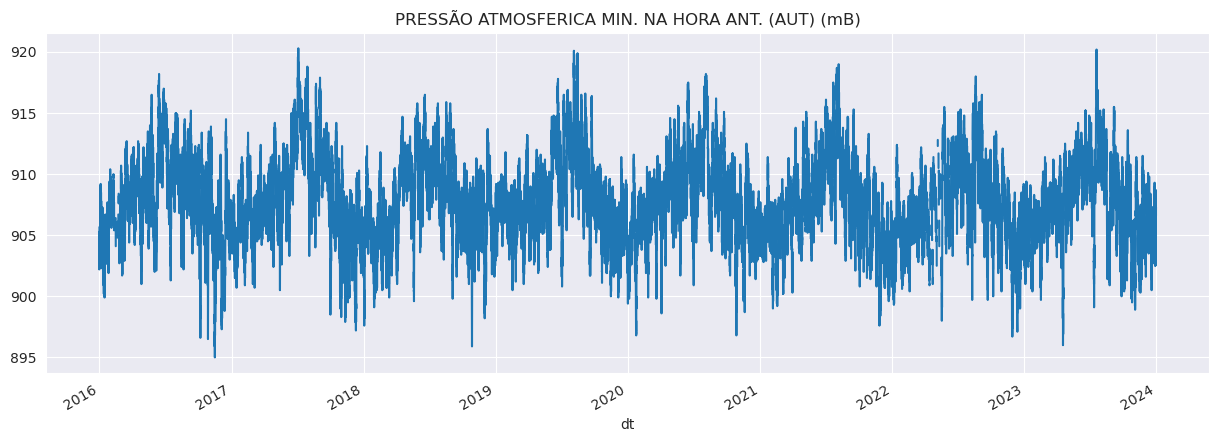

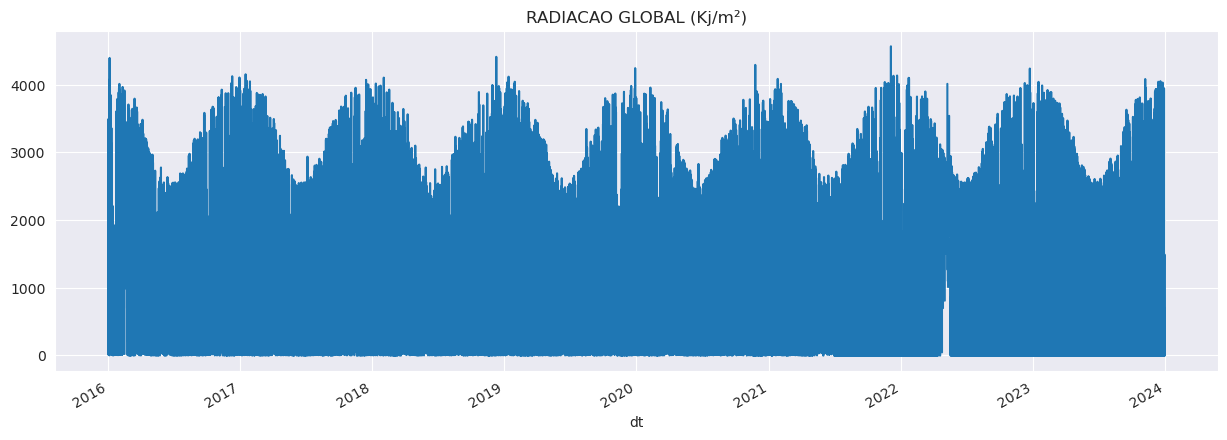

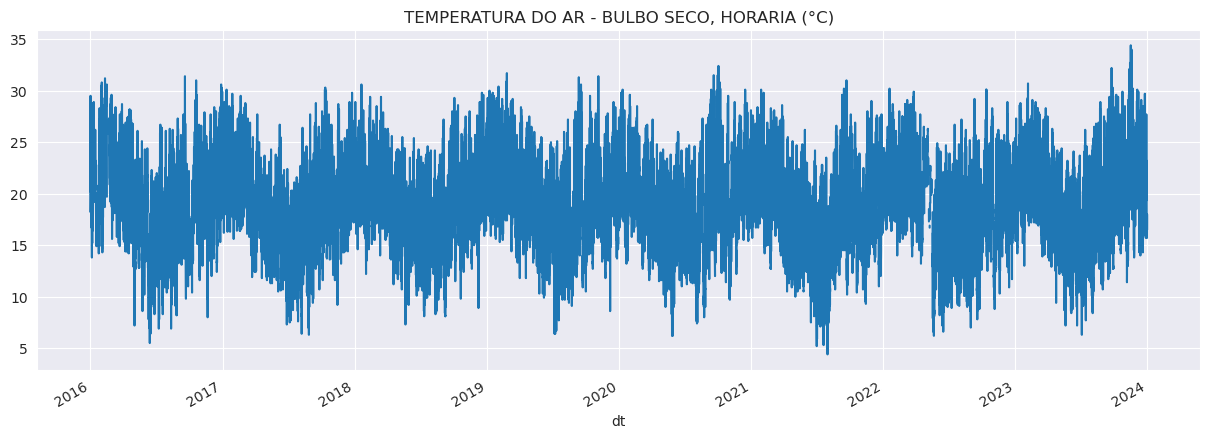

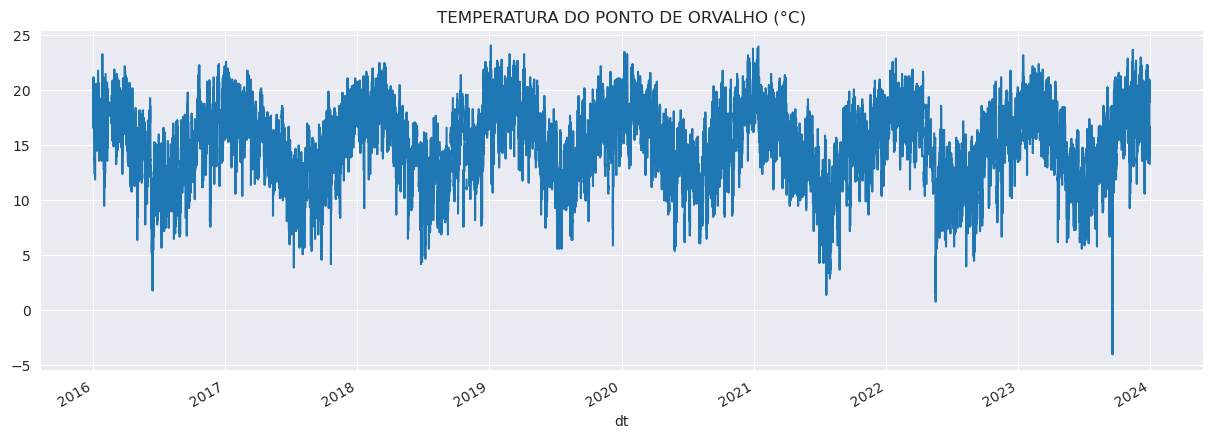

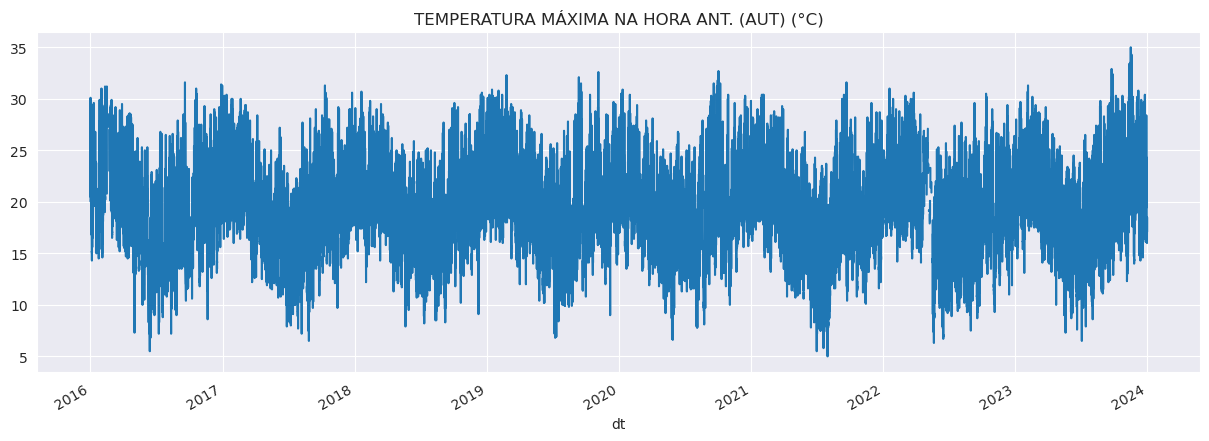

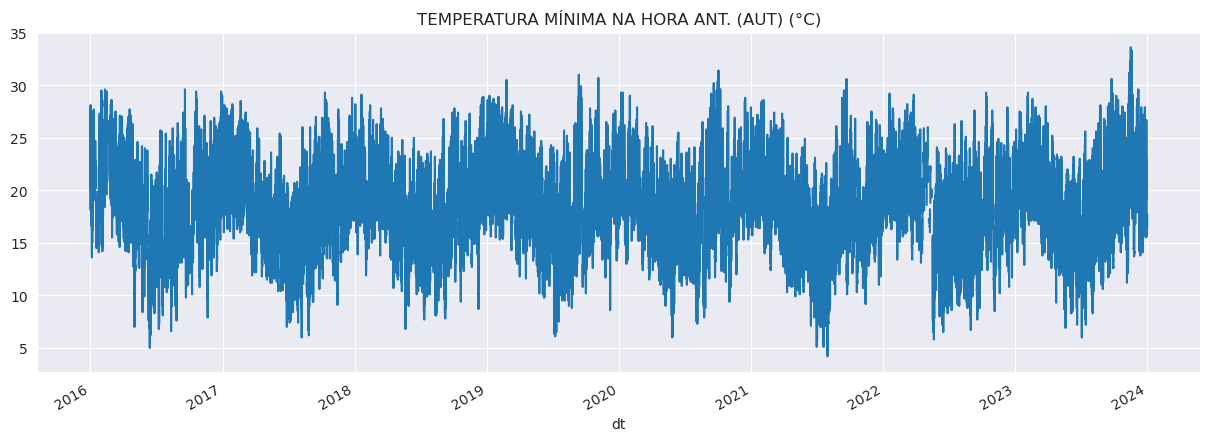

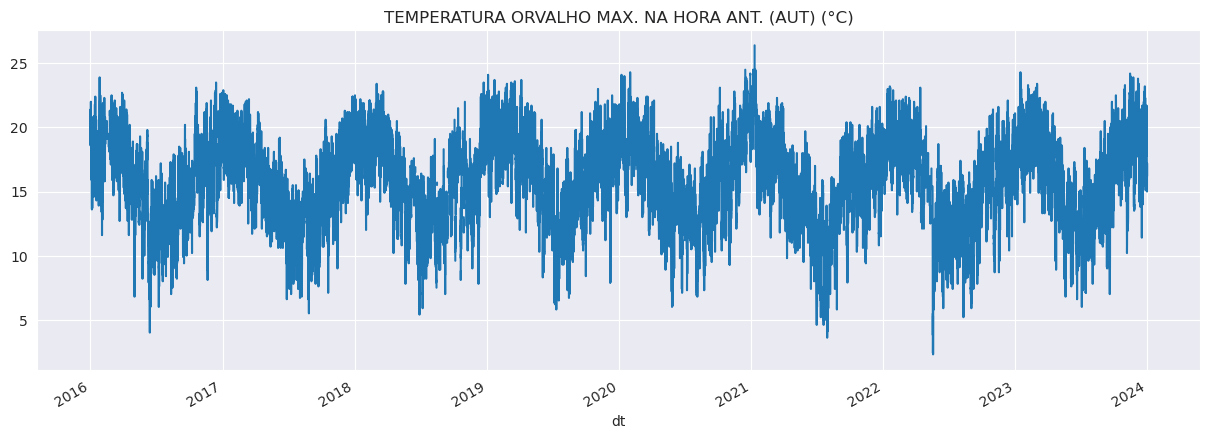

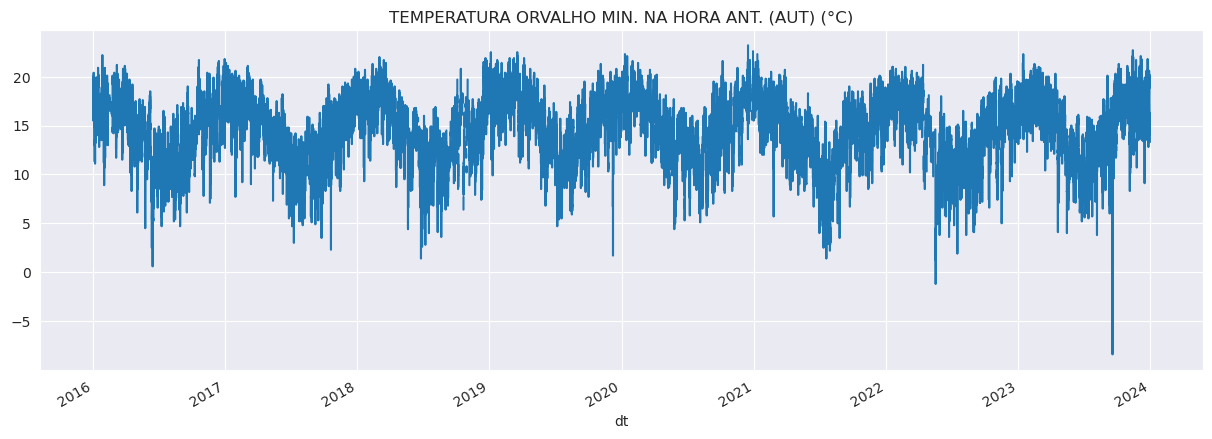

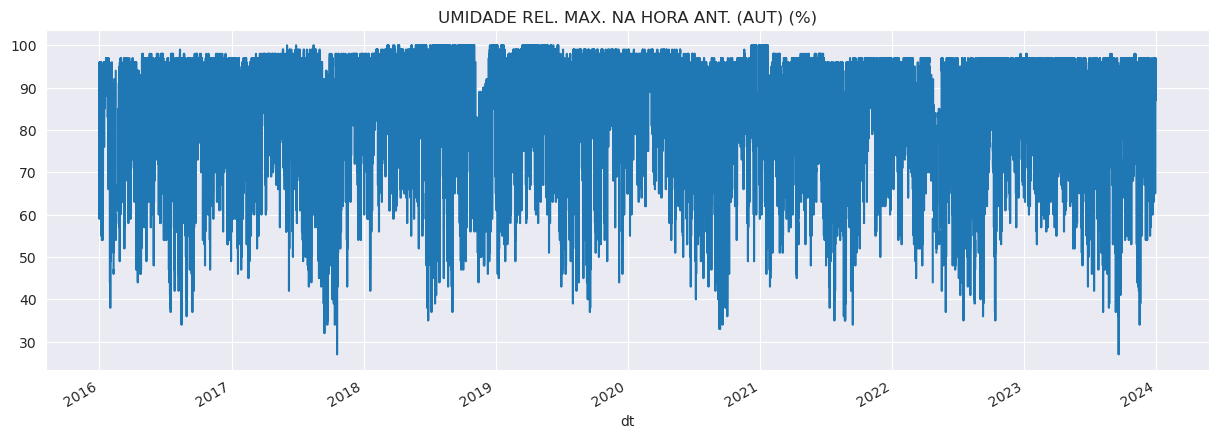

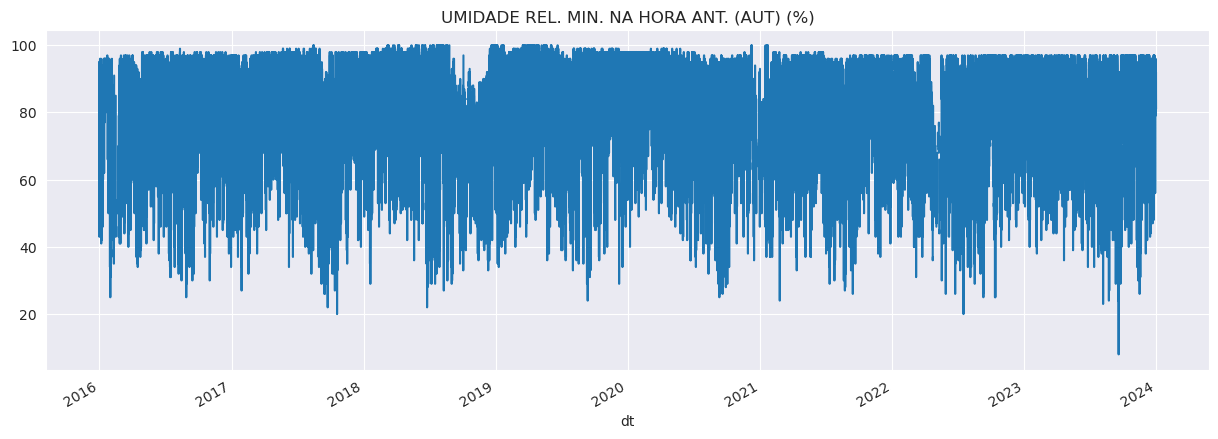

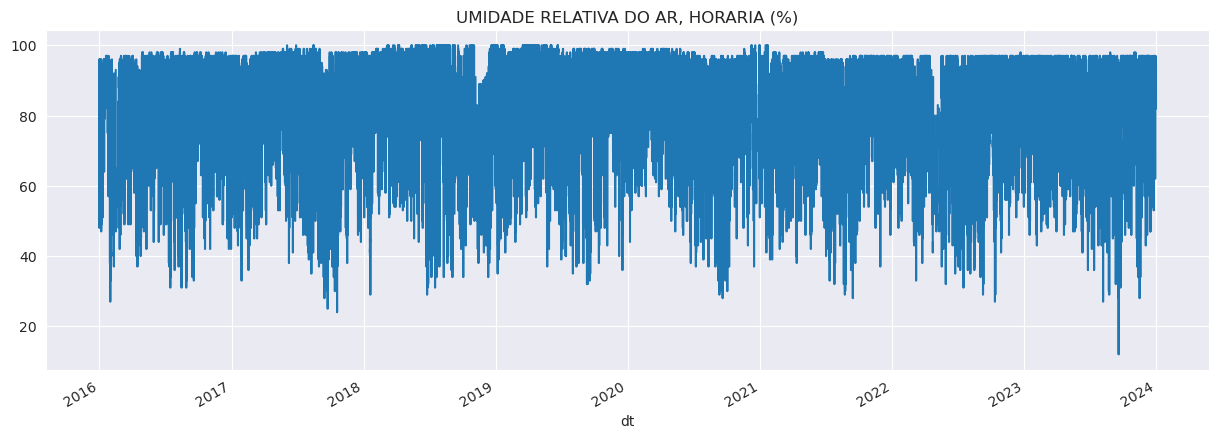

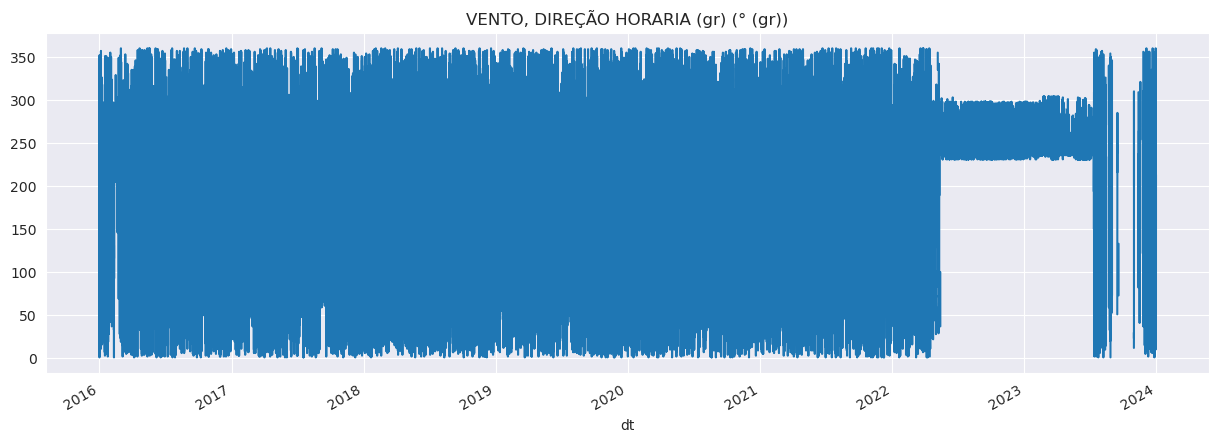

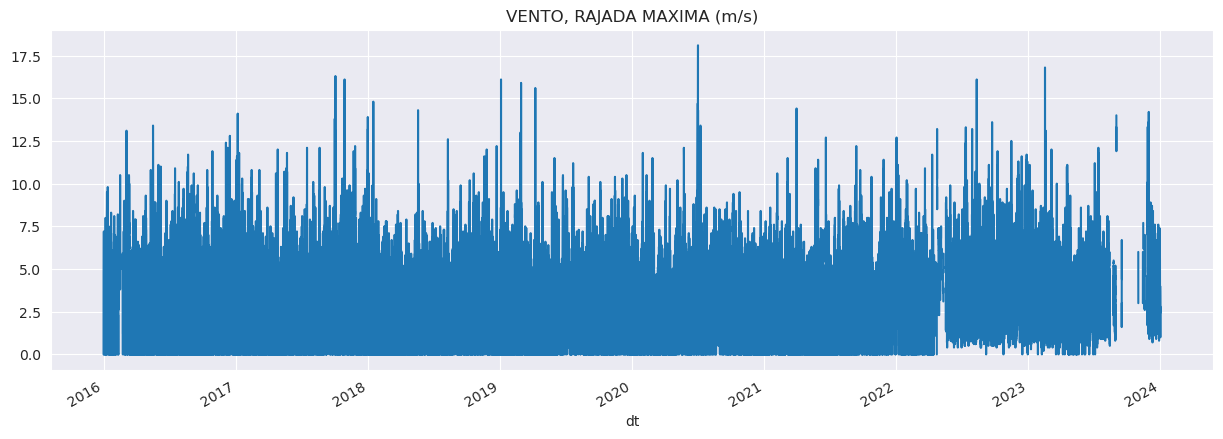

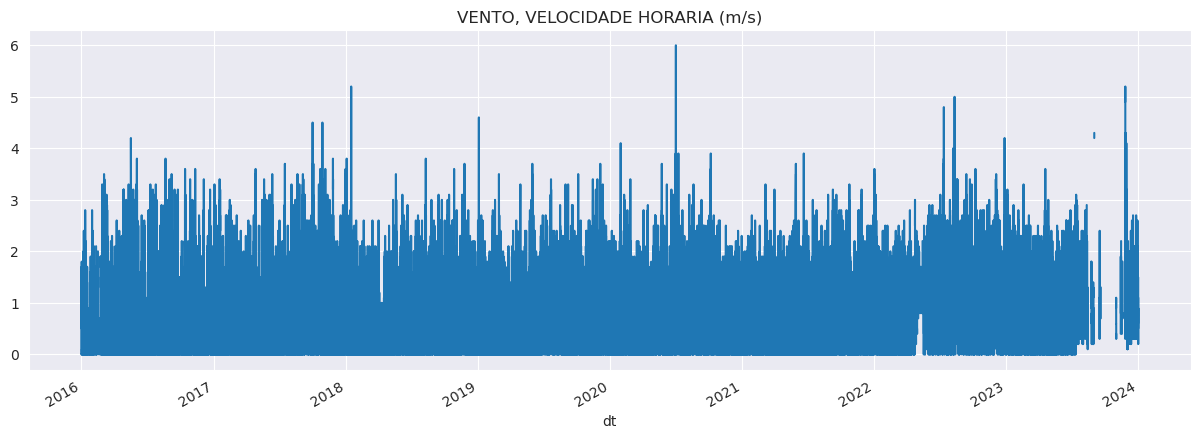

In [144]:

cleaned_weather_df = weather_df.copy()

for col in cleaned_weather_df.columns:
    cleaned_weather_df[col] = cleaned_weather_df[col].apply(lambda x: x if x > -900 else np.nan)

    cleaned_weather_df[col].plot(figsize=(15, 5), title=col)
    plt.title(col)
    plt.show()


# Análise de Correlação

               PREC_HOR  PRES_EST_HOR  PRES_MAX_ANT  PRES_MIN_ANT  RAD_GLOB  \
PREC_HOR       1.000000     -0.058423     -0.057543     -0.067800 -0.122739   
PRES_EST_HOR  -0.058423      1.000000      0.997270      0.997464  0.033013   
PRES_MAX_ANT  -0.057543      0.997270      1.000000      0.997777  0.067041   
PRES_MIN_ANT  -0.067800      0.997464      0.997777      1.000000  0.060726   
RAD_GLOB      -0.122739      0.033013      0.067041      0.060726  1.000000   
TEMP_AR_HOR   -0.040270     -0.462912     -0.448016     -0.452723  0.606450   
TEMP_ORV       0.088031     -0.547261     -0.547896     -0.548241  0.066423   
TEMP_MAX_ANT  -0.026094     -0.459361     -0.444605     -0.449158  0.591120   
TEMP_MIN_ANT  -0.026144     -0.494223     -0.479771     -0.483551  0.536414   
ORV_MAX_ANT    0.090012     -0.547856     -0.545449     -0.546898  0.165348   
ORV_MIN_ANT    0.100120     -0.540121     -0.542903     -0.542351 -0.027961   
UMID_MAX_ANT   0.147488      0.043169      0.023842 

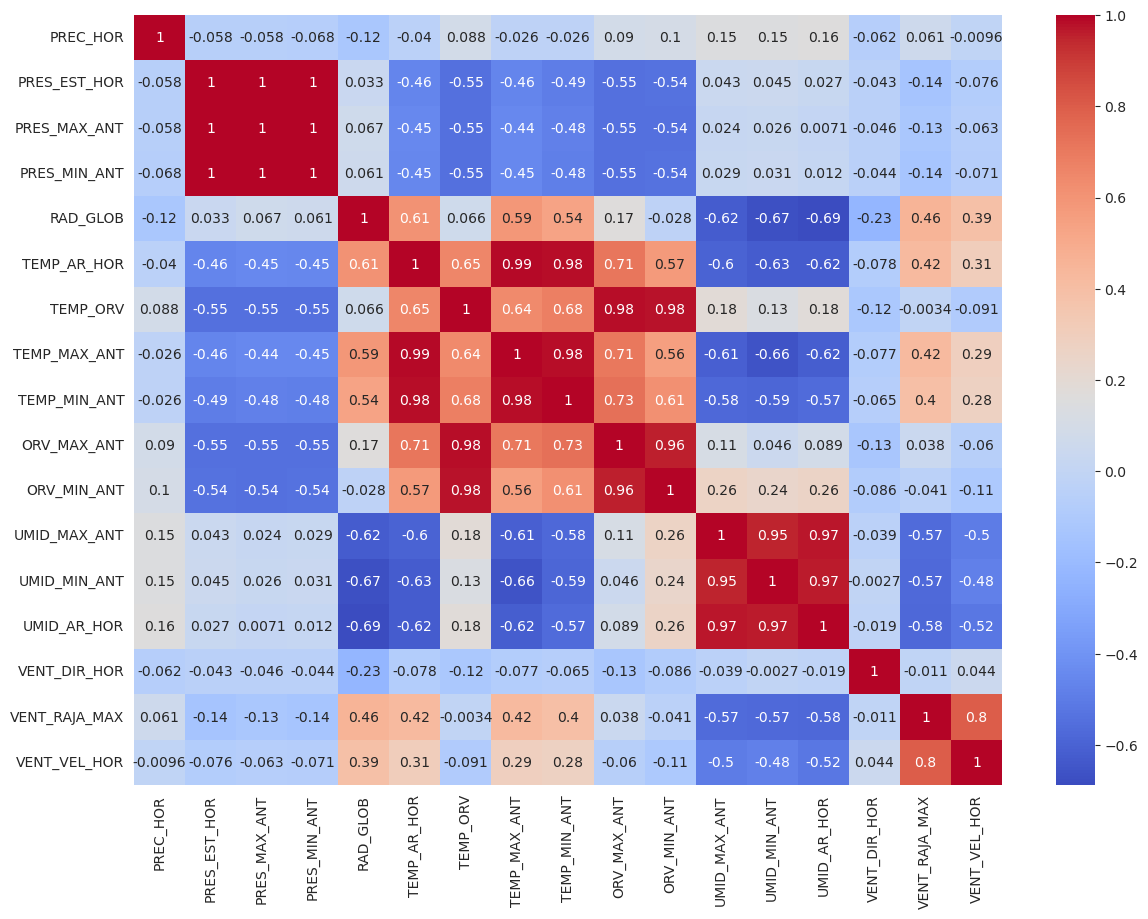

In [145]:
import seaborn as sns

"""
['Alface Americana - Roça',
 'Alface Crespa - Roça',
 'Alface Lisa - Roça',
 'Alface Americana - Atacado',
 'Alface Crespa - Atacado',
 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
 'c',
 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
 'RADIACAO GLOBAL (Kj/m²)',
 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
 'TEMPERATURA DO PONTO DE ORVALHO (°C)',
 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
 'UMIDADE RELATIVA DO AR, HORARIA (%)',
 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',
 'VENTO, RAJADA MAXIMA (m/s)',
 'VENTO, VELOCIDADE HORARIA (m/s)']
"""
rename_dict = {
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'PREC_HOR',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRES_EST_HOR',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRES_MAX_ANT',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRES_MIN_ANT',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD_GLOB',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TEMP_AR_HOR',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'TEMP_ORV',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MAX_ANT',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MIN_ANT',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'ORV_MAX_ANT',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'ORV_MIN_ANT',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'UMID_MAX_ANT',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'UMID_MIN_ANT',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'UMID_AR_HOR',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'VENT_DIR_HOR',
    'VENTO, RAJADA MAXIMA (m/s)': 'VENT_RAJA_MAX',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'VENT_VEL_HOR'
}
cleaned_weather_df.rename(columns=rename_dict, inplace=True)

# Compute correlation matrix
co_mtx = cleaned_weather_df.corr()

# Print correlation matrix
print(co_mtx)
plt.figure(figsize=(14, 10))
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="coolwarm", annot=True)

# Display heatmap
plt.show()



In [146]:
cleaned_weather_df.drop(columns=['PRES_EST_HOR','PRES_MAX_ANT', 'TEMP_MIN_ANT', 'TEMP_MAX_ANT', 'ORV_MIN_ANT','ORV_MAX_ANT','UMID_MAX_ANT', 'UMID_MIN_ANT', 'VENT_RAJA_MAX'], inplace=True)



              PREC_HOR  PRES_MIN_ANT  RAD_GLOB  TEMP_AR_HOR  TEMP_ORV  \
PREC_HOR      1.000000     -0.067800 -0.122739    -0.040270  0.088031   
PRES_MIN_ANT -0.067800      1.000000  0.060726    -0.452723 -0.548241   
RAD_GLOB     -0.122739      0.060726  1.000000     0.606450  0.066423   
TEMP_AR_HOR  -0.040270     -0.452723  0.606450     1.000000  0.650943   
TEMP_ORV      0.088031     -0.548241  0.066423     0.650943  1.000000   
UMID_AR_HOR   0.159240      0.012417 -0.687893    -0.622175  0.180102   
VENT_DIR_HOR -0.061544     -0.044260 -0.229142    -0.077766 -0.115265   
VENT_VEL_HOR -0.009580     -0.071223  0.390249     0.307183 -0.091402   

              UMID_AR_HOR  VENT_DIR_HOR  VENT_VEL_HOR  
PREC_HOR         0.159240     -0.061544     -0.009580  
PRES_MIN_ANT     0.012417     -0.044260     -0.071223  
RAD_GLOB        -0.687893     -0.229142      0.390249  
TEMP_AR_HOR     -0.622175     -0.077766      0.307183  
TEMP_ORV         0.180102     -0.115265     -0.091402  
UMID_A

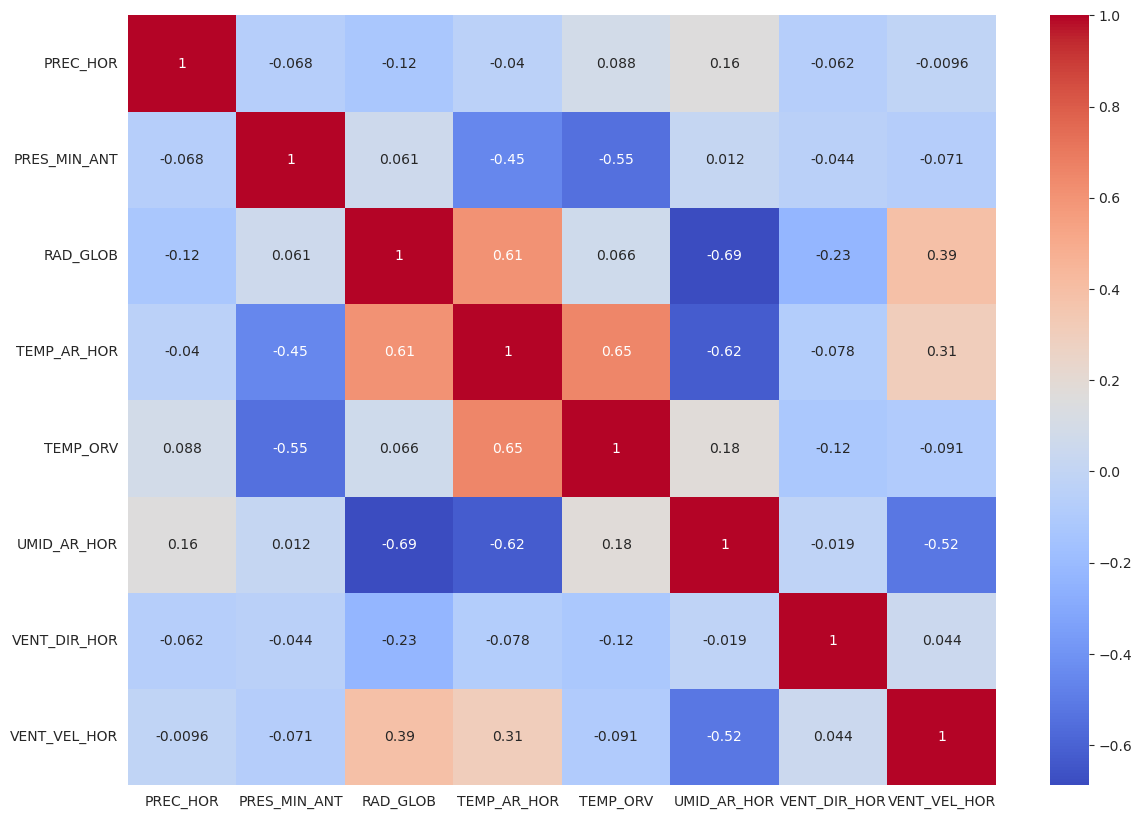

In [147]:
# Compute correlation matrix
co_mtx = cleaned_weather_df.corr()

# Print correlation matrix
print(co_mtx)
plt.figure(figsize=(14, 10))
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="coolwarm", annot=True)

# Display heatmap
plt.show()

In [148]:
cleaned_weather_df.index = pd.to_datetime(cleaned_weather_df.index, utc=True)
resampled_cleaned_weather_df = pd.DataFrame(index=cleaned_weather_df.resample('W').sum().index)
resampled_cleaned_weather_df

""
dt
2016-01-03 00:00:00+00:00
2016-01-10 00:00:00+00:00
2016-01-17 00:00:00+00:00
2016-01-24 00:00:00+00:00
2016-01-31 00:00:00+00:00
...
2023-12-03 00:00:00+00:00
2023-12-10 00:00:00+00:00
2023-12-17 00:00:00+00:00


array([<Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>], dtype=object)

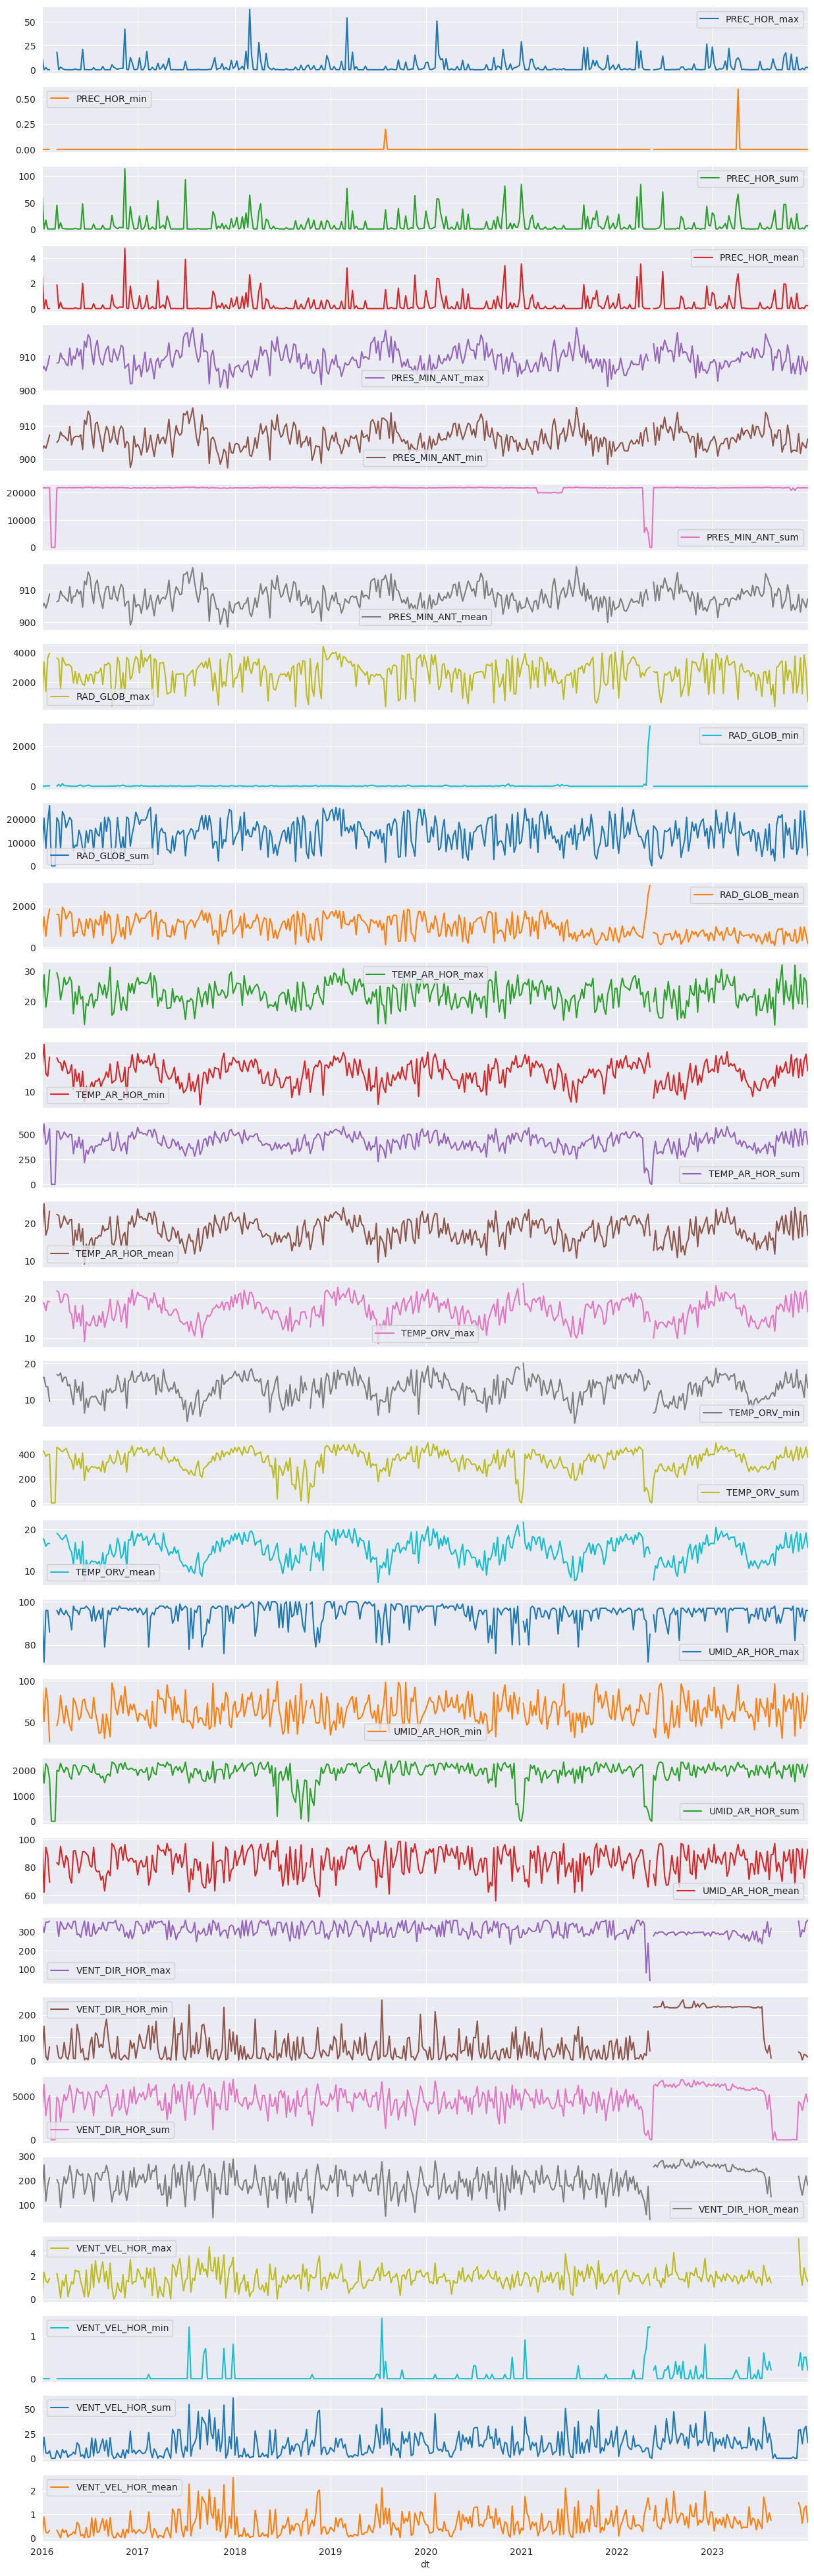

In [149]:

for col in cleaned_weather_df.columns:
    resampled_col = cleaned_weather_df[col].resample('D')
    #resampled_cleaned_weather_df[col] = resampled_col
    resampled_cleaned_weather_df[f'{col}_max'] = resampled_col.max()
    resampled_cleaned_weather_df[f'{col}_min'] = resampled_col.min()
    resampled_cleaned_weather_df[f'{col}_sum'] = resampled_col.sum()
    resampled_cleaned_weather_df[f'{col}_mean'] = resampled_col.mean()
    #resampled_cleaned_weather_df[f'{col}_std'] = resampled_col.std()
    #resampled_cleaned_weather_df[f'{col}_var'] = resampled_col.var()

def plot_col_variants(col_name):
    #resampled_cleaned_weather_df[f'{col_name}'].plot()
    plt.figure(figsize=(14, 10))
    ax = plt.subplot(5, 1, 1)
    resampled_cleaned_weather_df[f'{col_name}_max'].plot()
    resampled_cleaned_weather_df[f'{col_name}_min'].plot()
    resampled_cleaned_weather_df[f'{col_name}_sum'].plot()
    resampled_cleaned_weather_df[f'{col_name}_mean'].plot()
    resampled_cleaned_weather_df[f'{col_name}_std'].plot()
    resampled_cleaned_weather_df[f'{col_name}_var'].plot()
    plt.show()

resampled_cleaned_weather_df.plot(figsize=(15, 50), subplots=True)


In [150]:
from datetime import  timedelta
aligned_dates = [price_df.index[0] + timedelta(weeks=i) for i in range(len(price_df))]
aligned_dates

[Timestamp('2016-04-22 00:00:00+0000', tz='UTC'),
 Timestamp('2016-04-29 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-06 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-13 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-20 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-27 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-03 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-10 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-17 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-24 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-01 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-08 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-15 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-22 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-29 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-05 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-12 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-19 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-26 00:00:00+0000', tz='UTC'),
 Timestamp('2016-09-02 00:00:00+0000', tz='UTC'),


[6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,


In [151]:
resampled_cleaned_weather_df["week_year"] = (
                resampled_cleaned_weather_df.index - resampled_cleaned_weather_df.index.isocalendar().weekday * timedelta(days=1))


AttributeError: 'DataFrame' object has no attribute 'weekday'

In [137]:
resampled_cleaned_weather_df.index

Index([53,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       43, 44, 45, 46, 47, 48, 49, 50, 51, 52],
      dtype='UInt32', name='week', length=418)

In [ ]:
#resampled_cleaned_weather_df.index = resampled_cleaned_weather_df.index.isocalendar().week

In [94]:
resampled_cleaned_weather_df

,PREC_HOR_max,PREC_HOR_min,PREC_HOR_sum,PREC_HOR_mean,PRES_MIN_ANT_max,PRES_MIN_ANT_min,PRES_MIN_ANT_sum,PRES_MIN_ANT_mean,RAD_GLOB_max,RAD_GLOB_min,...,UMID_AR_HOR_sum,UMID_AR_HOR_mean,VENT_DIR_HOR_max,VENT_DIR_HOR_min,VENT_DIR_HOR_sum,VENT_DIR_HOR_mean,VENT_VEL_HOR_max,VENT_VEL_HOR_min,VENT_VEL_HOR_sum,VENT_VEL_HOR_mean
week,,,,,,,,,,,,,,,,,,,,,
53,11.8,0.0,61.4,2.558333,906.2,902.9,21710.1,904.587500,1250.2,0.0,...,2268.0,94.500000,337.0,30.0,3618.0,150.750000,0.6,0.0,2.2,0.091667
1,0.0,0.0,0.0,0.000000,907.2,903.9,21740.6,905.858333,3360.3,9.5,...,1498.0,62.416667,296.0,150.0,6364.0,265.166667,2.3,0.0,21.3,0.887500
2,2.2,0.0,16.8,0.700000,905.9,903.2,21705.5,904.395833,1349.7,14.1,...,2263.0,94.291667,351.0,17.0,2783.0,115.958333,1.6,0.0,5.5,0.229167
3,0.0,0.0,0.0,0.000000,907.7,905.0,21746.2,906.091667,3610.3,26.6,...,2130.0,88.750000,349.0,2.0,4317.0,179.875000,1.4,0.0,4.9,0.204167
4,0.0,0.0,0.0,0.000000,910.4,907.3,21810.1,908.754167,3947.7,15.8,...,1667.0,69.458333,355.0,60.0,5107.0,212.791667,1.8,0.0,7.7,0.320833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,0.0,0.0,0.0,0.000000,904.8,901.6,21676.1,903.170833,3648.2,0.0,...,1895.0,78.958333,272.0,32.0,4178.0,174.083333,2.2,0.6,29.2,1.216667
49,1.6,0.0,1.8,0.075000,910.1,905.0,21774.6,907.275000,1194.1,0.0,...,2236.0,93.166667,309.0,2.0,3372.0,140.500000,1.2,0.2,14.8,0.616667
50,0.0,0.0,0.0,0.000000,907.5,904.0,21743.1,905.962500,3829.1,0.0,...,1738.0,72.416667,299.0,27.0,4384.0,182.666667,2.7,0.5,29.4,1.225000


In [74]:
resampled_cleaned_weather_df.isna().sum()

PREC_HOR_max          4
PREC_HOR_min          4
PREC_HOR_sum          0
PREC_HOR_mean         4
PRES_MIN_ANT_max      5
PRES_MIN_ANT_min      5
PRES_MIN_ANT_sum      0
PRES_MIN_ANT_mean     5
RAD_GLOB_max          4
RAD_GLOB_min          4
RAD_GLOB_sum          0
RAD_GLOB_mean         4
TEMP_AR_HOR_max       4
TEMP_AR_HOR_min       4
TEMP_AR_HOR_sum       0
TEMP_AR_HOR_mean      4
TEMP_ORV_max          6
TEMP_ORV_min          6
TEMP_ORV_sum          0
TEMP_ORV_mean         6
UMID_AR_HOR_max       6
UMID_AR_HOR_min       6
UMID_AR_HOR_sum       0
UMID_AR_HOR_mean      6
VENT_DIR_HOR_max     16
VENT_DIR_HOR_min     16
VENT_DIR_HOR_sum      0
VENT_DIR_HOR_mean    16
VENT_VEL_HOR_max     16
VENT_VEL_HOR_min     16
VENT_VEL_HOR_sum      0
VENT_VEL_HOR_mean    16
dtype: int64

In [ ]:
price_weather_df = resampled_cleaned_weather_df.copy()


---

In [75]:
# price_weather_df = pd.read_csv('../../processed_data/price_weather_weekly_df-2016-2023.csv',index_col='dt', parse_dates=True)
# price_weather_df.drop(columns=['first_day_week'], inplace=True)
# price_weather_df
# price_weather_df.columns.tolist()

,Alface Americana - Roça,Alface Crespa - Roça,Alface Lisa - Roça,Alface Americana - Atacado,Alface Crespa - Atacado,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),...,TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
dt,,,,,,,,,,,,,,,,,,,,,
2016-04-24 00:00:00+00:00,0.592500,0.616500,0.618000,NaN,NaN,0.000000,907.386111,907.597222,907.213889,805.462393,...,21.968056,20.484722,16.069444,14.787500,75.597222,67.736111,71.763889,219.597222,1.976389,0.140278
2016-05-01 00:00:00+00:00,1.000000,0.426111,0.500000,NaN,NaN,0.145238,905.865476,906.075000,905.628571,358.881090,...,17.910119,17.040476,14.511310,13.772024,84.839286,81.220238,83.279762,174.041667,3.461905,0.521429
2016-05-08 00:00:00+00:00,1.041667,0.437778,0.479444,NaN,NaN,0.021429,909.642262,909.846429,909.453571,559.004533,...,16.691667,15.564881,14.151786,13.103571,88.702381,83.500000,86.303571,197.541667,1.684524,0.204762
2016-05-15 00:00:00+00:00,1.055833,0.430556,0.430556,NaN,NaN,0.215476,909.359524,909.569643,909.135714,346.476328,...,17.743452,16.867262,15.407143,14.588095,89.601190,84.839286,87.196429,189.976190,2.242262,0.270238
2016-05-22 00:00:00+00:00,0.764167,0.444444,0.398333,NaN,NaN,0.115476,908.848810,909.090476,908.598810,406.224192,...,18.666667,17.812500,15.844643,15.135119,87.083333,82.839286,84.976190,208.922619,3.440476,0.574405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-03 00:00:00+00:00,1.875000,0.750000,0.750000,1.0,0.5,0.077381,905.600595,905.836012,905.375595,671.860714,...,21.935119,20.800893,18.759821,17.689583,86.452381,79.440476,83.136905,183.988095,4.221131,1.291071
2023-12-10 00:00:00+00:00,1.458333,0.677083,0.677083,1.0,0.5,0.697619,906.600000,906.830357,906.368452,649.313690,...,21.825000,20.777976,19.458929,18.419643,90.095238,84.946429,87.648810,154.059524,3.461310,0.982738
2023-12-17 00:00:00+00:00,1.125000,0.562500,0.562500,1.0,0.5,0.347619,906.604464,906.823512,906.398512,776.282738,...,20.994940,19.836310,17.822917,16.600000,86.422619,79.940476,83.294643,186.979167,3.731845,1.075595


['Alface Americana - Roça',
 'Alface Crespa - Roça',
 'Alface Lisa - Roça',
 'Alface Americana - Atacado',
 'Alface Crespa - Atacado',
 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
 'RADIACAO GLOBAL (Kj/m²)',
 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
 'TEMPERATURA DO PONTO DE ORVALHO (°C)',
 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
 'UMIDADE RELATIVA DO AR, HORARIA (%)',
 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',
 'VENTO, RAJADA MAXIMA (m/s)',
 'VENTO, VELOCIDADE HORARIA (m/s)']